# 04 — MobileNet Transfer Learning
## Deepfake Face Detection — Kaggle GPU

**Model:** MobileNet pretrained ImageNet → fine-tune cho deepfake detection  
**Dựa trên:** Deepfakeimagedetection paper — MobileNet đạt **96.96%** trên cùng dataset StyleGAN  
**Tại sao V1 thay vì V2:** Paper dùng V1 trên đúng dataset StyleGAN của bạn và đạt cao hơn V2

## 0. Setup

In [1]:
import os, sys, warnings, glob, pathlib
warnings.filterwarnings('ignore')

# ── Path setup ──────────────────────────────────────────────────────────────────
PROJECT_ROOT = pathlib.Path.cwd().parent   # notebooks/ → project root
sys.path.insert(0, str(PROJECT_ROOT / "src"))

OUTPUT_DIR  = str(PROJECT_ROOT / "notebooks" / "output")
MODELS_DIR  = str(PROJECT_ROOT / "models")
REPORTS_DIR = str(PROJECT_ROOT / "reports")
os.makedirs(MODELS_DIR,  exist_ok=True)
os.makedirs(REPORTS_DIR, exist_ok=True)
os.makedirs(OUTPUT_DIR,  exist_ok=True)

DATA_DIR = str(PROJECT_ROOT / "data" / "raw")

# ── Imports ─────────────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from dataset  import build_dataframe, split_dataframe, make_tf_dataset
from evaluate import evaluate_model

SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)

# ── Config ──────────────────────────────────────────────────────────────────────
IMG_SIZE     = 224
BATCH_SIZE   = 32
EPOCHS_FROZEN = 10   # Phase 1: chỉ train classifier head, base frozen
EPOCHS_FINETUNE = 20 # Phase 2: unfreeze top layers, fine-tune toàn bộ
LR_FROZEN    = 1e-3  # lr cao hơn khi frozen — chỉ train head
LR_FINETUNE  = 1e-4  # lr thấp hơn khi fine-tune — tránh phá weights pretrained
DROPOUT_RATE = 0.5

print("✅ Setup xong")
print(f"   GPU    : {tf.config.list_physical_devices('GPU')}")
print(f"   TF     : {tf.__version__}")
print(f"   Data   : {DATA_DIR}")


2026-06-01 02:59:33.021396: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1780282773.519731      24 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1780282773.657236      24 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1780282774.940680      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780282774.940721      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780282774.940724      24 computation_placer.cc:177] computation placer alr

✅ Setup xong
   GPU    : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]
   TF     : 2.19.0
   Data   : /kaggle/input/datasets/troykueh/real-vs-fake-faces-stylegan3


## 1. Load dữ liệu

Giống hệt các notebook trước — dùng lại `dataset.py`.

In [2]:
IMG_TUPLE = (IMG_SIZE, IMG_SIZE)

df = build_dataframe(DATA_DIR)
train_df, val_df, test_df = split_dataframe(df)
print(f"Train: {len(train_df):,} | Val: {len(val_df):,} | Test: {len(test_df):,}")

train_ds = make_tf_dataset(train_df, img_size=IMG_TUPLE, batch_size=BATCH_SIZE,
                           augment=True,  shuffle=True)
val_ds   = make_tf_dataset(val_df,   img_size=IMG_TUPLE, batch_size=BATCH_SIZE,
                           augment=False, shuffle=False)
test_ds  = make_tf_dataset(test_df,  img_size=IMG_TUPLE, batch_size=BATCH_SIZE,
                           augment=False, shuffle=False)

for images, labels in train_ds.take(1):
    print(f"Batch : {images.shape}")
    print(f"Range : [{images.numpy().min():.2f}, {images.numpy().max():.2f}]")

Train: 14,000 | Val: 3,000 | Test: 3,000


I0000 00:00:1780282796.567045      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1780282796.573143      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Batch : (32, 224, 224, 3)
Range : [0.00, 1.00]


## 2. Build Model — MobileNet Transfer Learning

### Transfer Learning là gì?

MobileNet đã được train trên **ImageNet (1.2M ảnh, 1000 classes)** — nó đã học được rất nhiều features hữu ích: cạnh, texture, hình dạng, vân da mặt.

Thay vì học từ đầu như CNN v2, ta **tái sử dụng những gì V1 đã học** và chỉ thêm classifier head mới cho bài toán fake/real.

### MobileNet vs MobileNetV2

| | MobileNet | MobileNetV2 |
|---|---|---|
| Năm | 2017 | 2018 |
| Cơ chế | Depthwise Separable Conv | + Inverted Residuals + Linear Bottleneck |
| Params | 3.36M | 3.4M |
| StyleGAN deepfake | **96.96%** (paper) | 81.3% (kết quả của bạn) |
| Lý do V1 tốt hơn | Ít nén thông tin hơn → giữ được GAN artifacts | Bottleneck nén quá mạnh → mất artifact |

### 2-Phase Training Strategy

```
Phase 1 — Frozen (10 epochs):
    Base MobileNet: FROZEN (không train)
    Classification head: TRAIN
    lr = 1e-3 (cao — chỉ học head)

Phase 2 — Fine-tune (20 epochs):
    Base MobileNet: UNFREEZE top 30 layers
    Toàn bộ: TRAIN
    lr = 1e-4 (thấp — tránh phá pretrained weights)
```

Tại sao 2 phases? Nếu unfreeze ngay từ đầu với lr cao → gradient lớn phá hủy toàn bộ ImageNet weights đã học.

In [3]:
def build_mobilenet(img_size=224, dropout_rate=0.5, learning_rate=1e-3):
    """
    MobileNet Transfer Learning cho deepfake detection.

    Theo paper Deepfakeimagedetection:
    - Base: MobileNet pretrained ImageNet, include_top=False
    - Head: GlobalAveragePooling2D → Dense → Dropout → Sigmoid
    - Training: 20 epochs (paper), batch_size=32
    - Kết quả paper: 96.96% trên cùng dataset StyleGAN
    """
    # ── Base model: MobileNet pretrained ────────────────────────────────────
    # include_top=False: bỏ classification head gốc của ImageNet
    # weights='imagenet': load pretrained weights
    base_model = keras.applications.MobileNet(
        input_shape=(img_size, img_size, 3),
        include_top=False,
        weights='imagenet',
    )
    # Frozen toàn bộ base — chỉ train head ở Phase 1
    base_model.trainable = False

    # ── Classification Head ───────────────────────────────────────────────────
    inputs  = keras.Input(shape=(img_size, img_size, 3), name='input')

    # Preprocessing: MobileNet cần input trong [-1, 1]
    # Input của bạn là [0,1] → cần rescale
    x = layers.Rescaling(scale=2.0, offset=-1.0, name='rescale')(inputs)

    # Base model (frozen)
    x = base_model(x, training=False)  # training=False để BatchNorm không update

    # Pooling → vector
    x = layers.GlobalAveragePooling2D(name='gap')(x)

    # Classifier — theo paper: 2 Dense layers
    x = layers.Dense(256, activation='relu', name='dense1')(x)
    x = layers.Dropout(dropout_rate, name='dropout')(x)

    # Output: P(ảnh là real) — fake=0, real=1
    outputs = layers.Dense(1, activation='sigmoid', name='output')(x)

    model = keras.Model(inputs=inputs, outputs=outputs, name='MobileNet_TL')
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss='binary_crossentropy',
        metrics=['accuracy'],
    )
    return model, base_model


model, base_model = build_mobilenet(IMG_SIZE, DROPOUT_RATE, LR_FROZEN)
model.summary()
print(f"\nBase model layers: {len(base_model.layers)}")
print(f"Trainable params (Phase 1 — head only): {model.trainable_variables.__len__()}")

17225924/17225924 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "MobileNet_TL"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescale (Rescaling)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenet_1.00_224 (Functional) │ (None, 7, 7, 1024)     │     3,228,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gap (GlobalAveragePooling2D)    │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense1 (Dense)                  │ (None, 256)            │       262,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,491,521 (13.32 MB)

 Trainable params: 262,657 (1.00 MB)

 Non-trainable params: 3,228,864 (12.32 MB)


Base model layers: 86
Trainable params (Phase 1 — head only): 4


## 3. Training — Phase 1: Frozen Base

Chỉ train classification head. Base MobileNet bị frozen hoàn toàn.  
Mục tiêu: head học được task deepfake trước khi fine-tune.

In [4]:
MODEL_PATH = os.path.join(MODELS_DIR, 'mobilenet_best.keras')

callbacks_phase1 = [
    keras.callbacks.ModelCheckpoint(
        filepath=MODEL_PATH,
        monitor='val_loss',
        save_best_only=True,
        verbose=1,
    ),
    keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True,
        verbose=1,
    ),
]

print(f"⏳ Phase 1 — Frozen base, train head only")
print(f"   Epochs={EPOCHS_FROZEN} | LR={LR_FROZEN}\n")

history_phase1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_FROZEN,
    callbacks=callbacks_phase1,
    verbose=1,
)

print(f"\n✅ Phase 1 xong!")
print(f"   Best val_acc : {max(history_phase1.history['val_accuracy']):.4f}")

⏳ Phase 1 — Frozen base, train head only
   Epochs=10 | LR=0.001

Epoch 1/10


I0000 00:00:1780282803.711821      70 service.cc:152] XLA service 0x7c8da0126a30 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1780282803.711855      70 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1780282803.711858      70 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1780282804.564338      70 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-06-01 03:00:13.802611: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-01 03:00:13.939827: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
I0000 00:00:1780282815.640491      70 device_co

437/438 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - accuracy: 0.6423 - loss: 0.6572

2026-06-01 03:01:00.313756: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-01 03:01:00.452026: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


438/438 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step - accuracy: 0.6424 - loss: 0.6571

2026-06-01 03:01:20.654147: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-01 03:01:20.791519: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-01 03:01:20.929562: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.



Epoch 1: val_loss improved from None to 0.55432, saving model to /kaggle/working/models/mobilenet_best.keras

Epoch 1: finished saving model to /kaggle/working/models/mobilenet_best.keras
438/438 ━━━━━━━━━━━━━━━━━━━━ 82s 152ms/step - accuracy: 0.6670 - loss: 0.6160 - val_accuracy: 0.7273 - val_loss: 0.5543
Epoch 2/10
438/438 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.7092 - loss: 0.5619
Epoch 2: val_loss improved from 0.55432 to 0.54415, saving model to /kaggle/working/models/mobilenet_best.keras

Epoch 2: finished saving model to /kaggle/working/models/mobilenet_best.keras
438/438 ━━━━━━━━━━━━━━━━━━━━ 24s 55ms/step - accuracy: 0.7053 - loss: 0.5636 - val_accuracy: 0.7283 - val_loss: 0.5442
Epoch 3/10
438/438 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.7264 - loss: 0.5367
Epoch 3: val_loss improved from 0.54415 to 0.53304, saving model to /kaggle/working/models/mobilenet_best.keras

Epoch 3: finished saving model to /kaggle/working/models/mobilenet_best.keras
438/438 ━━━━━━━━

## 4. Training — Phase 2: Fine-tune Top Layers

Unfreeze 30 layers cuối của base model, train toàn bộ với lr nhỏ hơn.  
**Tại sao chỉ top 30?** Các layer đầu học low-level features (cạnh, màu) — universal, không cần thay đổi. Chỉ cần fine-tune các layer cuối học high-level features đặc thù cho khuôn mặt.

In [5]:
# Unfreeze top 30 layers của base model
base_model.trainable = True
total_layers = len(base_model.layers)
freeze_until = total_layers - 30

for i, layer in enumerate(base_model.layers):
    layer.trainable = (i >= freeze_until)

print(f"Total base layers : {total_layers}")
print(f"Frozen layers     : {freeze_until}")
print(f"Trainable layers  : {total_layers - freeze_until}")

# Recompile với lr nhỏ hơn
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LR_FINETUNE),
    loss='binary_crossentropy',
    metrics=['accuracy'],
)

callbacks_phase2 = [
    keras.callbacks.ModelCheckpoint(
        filepath=MODEL_PATH,
        monitor='val_loss',
        save_best_only=True,
        verbose=1,
    ),
    keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=7,
        restore_best_weights=True,
        verbose=1,
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=1e-7,
        verbose=1,
    ),
]

print(f"\n⏳ Phase 2 — Fine-tune top 30 layers")
print(f"   Epochs={EPOCHS_FINETUNE} | LR={LR_FINETUNE}\n")

history_phase2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_FINETUNE,
    callbacks=callbacks_phase2,
    verbose=1,
)

print(f"\n✅ Phase 2 xong!")
print(f"   Epochs thực tế : {len(history_phase2.history['loss'])}")
print(f"   Best val_loss  : {min(history_phase2.history['val_loss']):.4f}")
print(f"   Best val_acc   : {max(history_phase2.history['val_accuracy']):.4f}")

Total base layers : 86
Frozen layers     : 56
Trainable layers  : 30

⏳ Phase 2 — Fine-tune top 30 layers
   Epochs=20 | LR=0.0001

Epoch 1/20
438/438 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 0.7081 - loss: 0.9921
Epoch 1: val_loss improved from None to 0.78160, saving model to /kaggle/working/models/mobilenet_best.keras

Epoch 1: finished saving model to /kaggle/working/models/mobilenet_best.keras
438/438 ━━━━━━━━━━━━━━━━━━━━ 49s 81ms/step - accuracy: 0.7621 - loss: 0.6149 - val_accuracy: 0.7153 - val_loss: 0.7816 - learning_rate: 1.0000e-04
Epoch 2/20
438/438 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.8773 - loss: 0.2937
Epoch 2: val_loss improved from 0.78160 to 0.41426, saving model to /kaggle/working/models/mobilenet_best.keras

Epoch 2: finished saving model to /kaggle/working/models/mobilenet_best.keras
438/438 ━━━━━━━━━━━━━━━━━━━━ 25s 56ms/step - accuracy: 0.8845 - loss: 0.2834 - val_accuracy: 0.8323 - val_loss: 0.4143 - learning_rate: 1.0000e-04
Epoch 3/20
437/438 ━━

## 5. Learning Curves

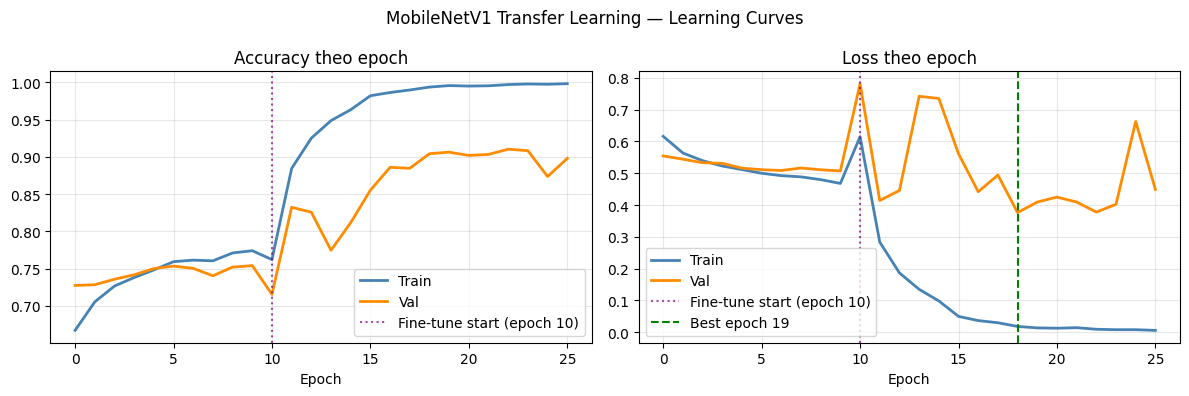

✅ Saved: /kaggle/working/reports/mobilenet_learning_curves.png


In [6]:
# Ghép history 2 phases để vẽ liền mạch
def combine_history(h1, h2):
    combined = {}
    for key in h1.history:
        combined[key] = h1.history[key] + h2.history[key]
    return combined

full_history = combine_history(history_phase1, history_phase2)
phase1_end   = len(history_phase1.history['loss'])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(full_history['accuracy'],     label='Train', color='steelblue',  linewidth=2)
axes[0].plot(full_history['val_accuracy'], label='Val',   color='darkorange', linewidth=2)
axes[0].axvline(phase1_end, color='purple', linestyle=':', alpha=0.7,
                label=f'Fine-tune start (epoch {phase1_end})')
axes[0].set_title('Accuracy theo epoch')
axes[0].set_xlabel('Epoch')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(full_history['loss'],     label='Train', color='steelblue',  linewidth=2)
axes[1].plot(full_history['val_loss'], label='Val',   color='darkorange', linewidth=2)
axes[1].axvline(phase1_end, color='purple', linestyle=':', alpha=0.7,
                label=f'Fine-tune start (epoch {phase1_end})')
best_ep = int(np.argmin(full_history['val_loss']))
axes[1].axvline(best_ep, color='green', linestyle='--',
                label=f'Best epoch {best_ep+1}')
axes[1].set_title('Loss theo epoch')
axes[1].set_xlabel('Epoch')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('MobileNet Transfer Learning — Learning Curves')
plt.tight_layout()
save_path = os.path.join(REPORTS_DIR, 'mobilenet_learning_curves.png')
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"✅ Saved: {save_path}")

## 6. Đánh giá trên Test Set

✅ Loaded: /kaggle/working/models/mobilenet_best.keras

  KẾT QUẢ: MobileNet
  Accuracy  : 0.9140  (91.40%)
  Precision : 0.9134
  Recall    : 0.9147
  F1-score  : 0.9141
  ROC-AUC   : 0.9687


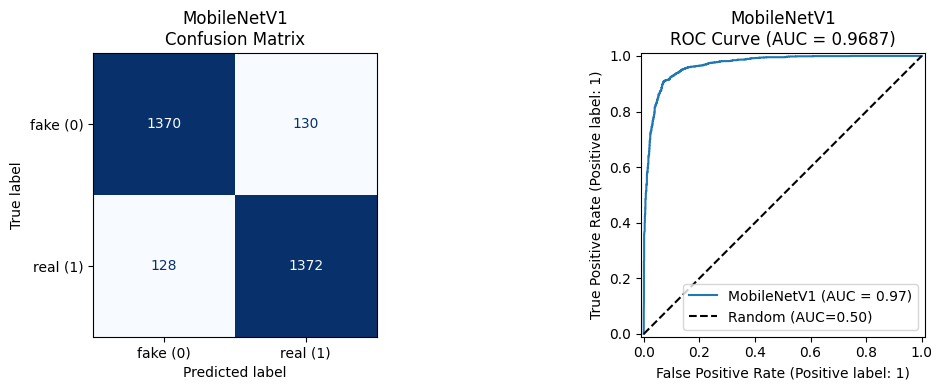

  Đã lưu biểu đồ → /kaggle/working/reports/mobilenet_evaluation.png


📊 So sánh:
   SVM + HOG     → Acc=72.3%  AUC=0.80
   Custom CNN v1 → Acc=59.8%  AUC=0.67  (underfitting)
   Custom CNN v2 → Acc=~85%+
   MobileNetV2   → Acc=81.3%
   MobileNet   → Acc=91.4%  AUC=0.97
   Paper target  → Acc=96.96%


In [7]:
best_model = keras.models.load_model(MODEL_PATH)
print(f"✅ Loaded: {MODEL_PATH}")

y_true, y_prob = [], []
for images, labels in test_ds:
    proba = best_model.predict(images, verbose=0)
    y_prob.extend(proba.flatten().tolist())
    y_true.extend(labels.numpy().tolist())

y_true = np.array(y_true)
y_prob = np.array(y_prob)
y_pred = (y_prob >= 0.5).astype(int)

results = evaluate_model(
    y_true     = y_true,
    y_pred     = y_pred,
    y_prob     = y_prob,
    model_name = 'MobileNet',
    save_dir   = REPORTS_DIR,
)

print("\n📊 So sánh:")
print(f"   SVM + HOG     → Acc=72.3%  AUC=0.80")
print(f"   Custom CNN v1 → Acc=59.8%  AUC=0.67  (underfitting)")
print(f"   Custom CNN v2 → Acc=~85%+")
print(f"   MobileNetV2   → Acc=81.3%")
print(f"   MobileNet   → Acc={results['accuracy']:.1%}  AUC={results['roc_auc']:.2f}")
print(f"   Paper target  → Acc=96.96%")

## 7. Lưu kết quả

In [8]:
RESULTS_CSV = os.path.join(REPORTS_DIR, 'all_results.csv')
df_new = pd.DataFrame([results])

if os.path.exists(RESULTS_CSV):
    df_old = pd.read_csv(RESULTS_CSV)
    df_old = df_old[df_old['model'] != results['model']]
    df_new = pd.concat([df_old, df_new], ignore_index=True)

df_new.to_csv(RESULTS_CSV, index=False)
print("✅ Lưu all_results.csv xong")
print("\n=== BẢNG SO SÁNH ===")
print(df_new.to_string(index=False))

print("\n📁 Output files:")
for root, dirs, files in os.walk(OUTPUT_DIR):
    for f in files:
        p = os.path.join(root, f)
        mb = os.path.getsize(p)/1024/1024
        print(f"   {p}  ({mb:.1f} MB)")
print("\n→ Save Version để download từ Output tab")

✅ Lưu all_results.csv xong

=== BẢNG SO SÁNH ===
      model  accuracy  precision  recall     f1  roc_auc
MobileNet     0.914     0.9134  0.9147 0.9141   0.9687

📁 Output files:
   /kaggle/working/__notebook__.ipynb  (2.9 MB)
   /kaggle/working/models/mobilenet_best.keras  (33.9 MB)
   /kaggle/working/reports/mobilenet_learning_curves.png  (0.1 MB)
   /kaggle/working/reports/all_results.csv  (0.0 MB)
   /kaggle/working/reports/mobilenet_evaluation.png  (0.1 MB)

→ Save Version để download từ Output tab
